# Phân tích dữ liệu bất động sản Việt Nam
Notebook này trả lời 5 câu hỏi dựa trên dữ liệu `batdongsan_vietnam1.csv`.

In [ ]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
path = 'batdongsan_vietnam1.csv'
df = pd.read_csv(path)
df['gia_m2'] = (df['gia_ban_ty_vnd'] * 1000 / df['dien_tich_m2']).round(2)
df['tinh_thanh'] = df['tinh_thanh'].str.strip()
th = df[df['tinh_thanh'] == 'Thái Nguyên']
print('loaded', len(df), 'rows')

loaded 50000 rows


## Câu 1: Các bất động sản có giá trị trên mỗi mét vuông cao nhất

In [3]:
# =========================================================
# CÂU 1
# =========================================================

print("="*70)
print("CÂU 1:")
print("Những bất động sản nào có giá trị")
print("trên mỗi mét vuông cao nhất?")
print("="*70)

# TOP 20 giá/m2 cao nhất
top_price_m2 = df.sort_values(
    'gia_m2',
    ascending=False
).head(20)

# Tạo bảng
bang_cau1 = top_price_m2[
    [
        'ma_tin',
        'tinh_thanh',
        'loai_bat_dong_san',
        'dien_tich_m2',
        'gia_ban_ty_vnd',
        'gia_m2'
    ]
]

# Hiện bảng
print("\nTOP 20 BẤT ĐỘNG SẢN GIÁ/m2 CAO NHẤT:\n")

print(
    bang_cau1.to_string(index=False)
)


CÂU 1:
Những bất động sản nào có giá trị
trên mỗi mét vuông cao nhất?

TOP 20 BẤT ĐỘNG SẢN GIÁ/m2 CAO NHẤT:

   ma_tin      tinh_thanh loai_bat_dong_san  dien_tich_m2  gia_ban_ty_vnd  gia_m2
BDS_43702 TP. Hồ Chí Minh          Biệt thự           345          126.95  367.97
BDS_43167 TP. Hồ Chí Minh          Biệt thự           249           91.53  367.59
BDS_19195 TP. Hồ Chí Minh          Biệt thự            31           11.39  367.42
BDS_37280 TP. Hồ Chí Minh          Biệt thự           191           70.17  367.38
 BDS_4522 TP. Hồ Chí Minh          Biệt thự           138           50.54  366.23
 BDS_6333 TP. Hồ Chí Minh          Biệt thự           312          113.81  364.78
BDS_43607 TP. Hồ Chí Minh          Biệt thự           142           51.67  363.87
 BDS_5429 TP. Hồ Chí Minh          Biệt thự           283          102.89  363.57
BDS_24041 TP. Hồ Chí Minh          Biệt thự           298          108.26  363.29
BDS_10638 TP. Hồ Chí Minh          Biệt thự           130           47.

## Câu 2: Giá trung bình theo loại hình bất động sản tại mỗi thành phố



CÂU 2:
Giá trung bình của từng loại hình bất động sản
tại mỗi thành phố là bao nhiêu?

BẢNG GIÁ TRUNG BÌNH:

     tinh_thanh loai_bat_dong_san  gia_ban_ty_vnd
     Bình Dương          Biệt thự       27.075623
     Bình Dương       Nhà mặt phố       17.381109
     Bình Dương           Đất nền       11.933009
     Bình Dương          Chung cư        7.085877
         Hà Nội          Biệt thự       42.796489
         Hà Nội       Nhà mặt phố       26.772170
         Hà Nội           Đất nền       18.895000
         Hà Nội          Chung cư       10.759830
TP. Hồ Chí Minh          Biệt thự       45.513162
TP. Hồ Chí Minh       Nhà mặt phố       28.461912
TP. Hồ Chí Minh           Đất nền       20.267811
TP. Hồ Chí Minh          Chung cư       11.346371
    Thái Nguyên          Biệt thự       19.629563
    Thái Nguyên       Nhà mặt phố       12.351271
    Thái Nguyên           Đất nền        8.874701
    Thái Nguyên          Chung cư        4.773541
        Đà Nẵng          Biệt thự      

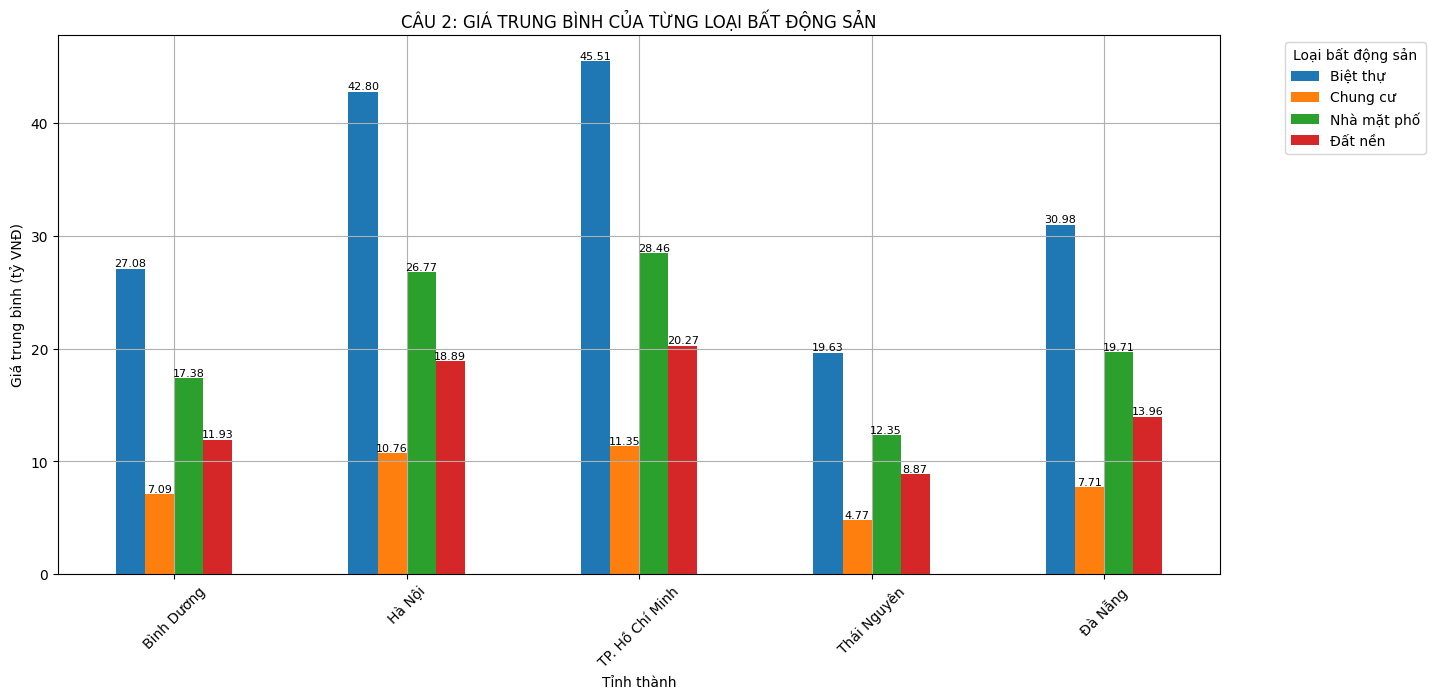

In [4]:
# =========================================================
# CÂU 2
# =========================================================

print("\n")
print("="*70)
print("CÂU 2:")
print("Giá trung bình của từng loại hình bất động sản")
print("tại mỗi thành phố là bao nhiêu?")
print("="*70)

# Tính giá trung bình
avg_price_by_type = df.groupby(
    [
        'tinh_thanh',
        'loai_bat_dong_san'
    ]
)['gia_ban_ty_vnd'].mean().reset_index()

# Sắp xếp dữ liệu
avg_price_by_type = avg_price_by_type.sort_values(
    [
        'tinh_thanh',
        'gia_ban_ty_vnd'
    ],
    ascending=[True, False]
)

# Hiện bảng
print("\nBẢNG GIÁ TRUNG BÌNH:\n")

print(
    avg_price_by_type.to_string(index=False)
)
# =========================================================
# BIỂU ĐỒ CÂU 2
# =========================================================

import matplotlib.pyplot as plt

# Pivot dữ liệu
pivot_avg = avg_price_by_type.pivot(
    index='tinh_thanh',
    columns='loai_bat_dong_san',
    values='gia_ban_ty_vnd'
)

# Vẽ biểu đồ
ax = pivot_avg.plot(
    kind='bar',
    figsize=(15,7)
)

# Tiêu đề
plt.title(
    'CÂU 2: GIÁ TRUNG BÌNH CỦA TỪNG LOẠI BẤT ĐỘNG SẢN'
)

# Tên trục
plt.xlabel('Tỉnh thành')

plt.ylabel('Giá trung bình (tỷ VNĐ)')

# Xoay tên tỉnh
plt.xticks(rotation=45)

# Lưới
plt.grid(True)

# Chú thích màu
plt.legend(
    title='Loại bất động sản',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# =========================================================
# HIỂN THỊ GIÁ TRỊ TRÊN TỪNG CỘT
# =========================================================

for container in ax.containers:

    ax.bar_label(
        container,
        fmt='%.2f',
        fontsize=8
    )

plt.show()

## Câu 3: Hệ số tương quan giữa diện tích và giá bất động sản ở mỗi thành phố



CÂU 3:
Hệ số tương quan giữa diện tích và giá
bất động sản ở mỗi thành phố là bao nhiêu?

CÔNG THỨC HỆ SỐ TƯƠNG QUAN PEARSON:

r = Σ[(xi - x̄)(yi - ȳ)] / √(Σ(xi - x̄)^2 * Σ(yi - ȳ)^2)

Trong đó:
- xi       : diện tích của từng bất động sản
- yi       : giá bán của từng bất động sản
- x̄        : diện tích trung bình
- ȳ        : giá bán trung bình
- (xi-x̄)  : độ lệch diện tích
- (yi-ȳ)  : độ lệch giá bán
- Σ        : tổng các giá trị
- r        : hệ số tương quan Pearson

Ý nghĩa:
- r gần 1  : diện tích tăng thì giá tăng mạnh
- r gần 0  : ít liên quan
- r gần -1 : diện tích tăng nhưng giá giảm

BẢNG PHÂN TÍCH TƯƠNG QUAN:

     tinh_thanh  dien_tich_trung_binh  gia_ban_trung_binh  dien_tich_bat_dong_san  gia_ban_bat_dong_san   (xi-x̄)   (yi-ȳ)  he_so_tuong_quan
        Đà Nẵng            189.216620           14.698898              189.216620             14.698898  0.283073 -1.118275          0.617699
         Hà Nội            190.245979           20.423297              190.2459

C:\Users\nguye\AppData\Local\Temp\ipykernel_13088\954415916.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


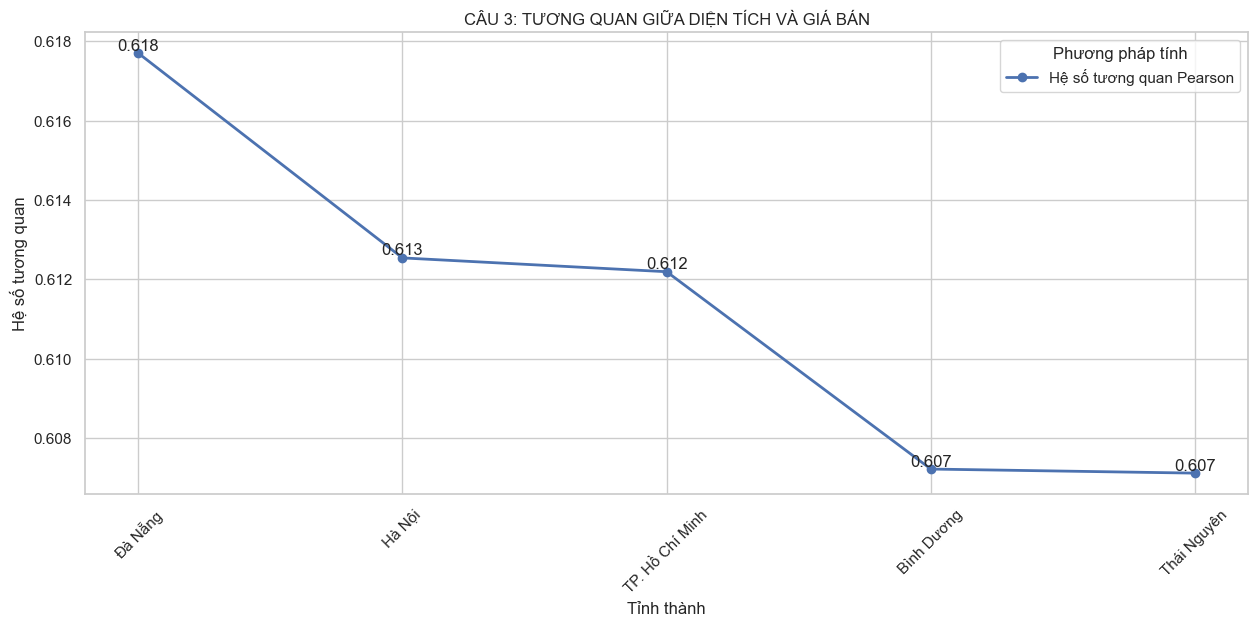

In [11]:
# =========================================================
# CÂU 3
# =========================================================

print("\n")
print("="*70)
print("CÂU 3:")
print("Hệ số tương quan giữa diện tích và giá")
print("bất động sản ở mỗi thành phố là bao nhiêu?")
print("="*70)

# =========================================================
# CÔNG THỨC TÍNH
# =========================================================

print("\nCÔNG THỨC HỆ SỐ TƯƠNG QUAN PEARSON:\n")

print("r = Σ[(xi - x̄)(yi - ȳ)] / √(Σ(xi - x̄)^2 * Σ(yi - ȳ)^2)")

print("\nTrong đó:")

print("- xi       : diện tích của từng bất động sản")
print("- yi       : giá bán của từng bất động sản")

print("- x̄        : diện tích trung bình")
print("- ȳ        : giá bán trung bình")

print("- (xi-x̄)  : độ lệch diện tích")
print("- (yi-ȳ)  : độ lệch giá bán")

print("- Σ        : tổng các giá trị")

print("- r        : hệ số tương quan Pearson")

print("\nÝ nghĩa:")

print("- r gần 1  : diện tích tăng thì giá tăng mạnh")
print("- r gần 0  : ít liên quan")
print("- r gần -1 : diện tích tăng nhưng giá giảm")

# =========================================================
# TẠO BẢNG PHÂN TÍCH
# =========================================================

corr_by_city = df.groupby(
    'tinh_thanh'
).agg({

    # diện tích trung bình
    'dien_tich_m2': 'mean',

    # giá bán trung bình
    'gia_ban_ty_vnd': 'mean'

}).reset_index()

# =========================================================
# THÊM CỘT HỆ SỐ TƯƠNG QUAN
# =========================================================

corr_by_city['he_so_tuong_quan'] = df.groupby(
    'tinh_thanh'
).apply(
    lambda g: g['dien_tich_m2'].corr(
        g['gia_ban_ty_vnd']
    )
).values

# =========================================================
# ĐỔI TÊN CỘT
# =========================================================

corr_by_city.columns = [

    'tinh_thanh',

    'dien_tich_trung_binh',

    'gia_ban_trung_binh',

    'he_so_tuong_quan'
]

# =========================================================
# THÊM 2 CỘT xi VÀ yi
# =========================================================

corr_by_city['dien_tich_bat_dong_san'] = (
    corr_by_city['dien_tich_trung_binh']
)

corr_by_city['gia_ban_bat_dong_san'] = (
    corr_by_city['gia_ban_trung_binh']
)

# =========================================================
# THÊM CÁC THÀNH PHẦN CÔNG THỨC PEARSON
# =========================================================

corr_by_city['(xi-x̄)'] = (
    corr_by_city['dien_tich_bat_dong_san']
    -
    corr_by_city['dien_tich_bat_dong_san'].mean()
)

corr_by_city['(yi-ȳ)'] = (
    corr_by_city['gia_ban_bat_dong_san']
    -
    corr_by_city['gia_ban_bat_dong_san'].mean()
)

# =========================================================
# SẮP XẾP THỨ TỰ CỘT
# =========================================================

corr_by_city = corr_by_city[[

    'tinh_thanh',

    'dien_tich_trung_binh',

    'gia_ban_trung_binh',

    'dien_tich_bat_dong_san',

    'gia_ban_bat_dong_san',

    '(xi-x̄)',

    '(yi-ȳ)',

    'he_so_tuong_quan'
]]

# =========================================================
# SẮP XẾP
# =========================================================

corr_by_city = corr_by_city.sort_values(
    'he_so_tuong_quan',
    ascending=False
)

# =========================================================
# HIỂN THỊ BẢNG
# =========================================================

print("\nBẢNG PHÂN TÍCH TƯƠNG QUAN:\n")

print(
    corr_by_city.to_string(index=False)
)

# =========================================================
# BIỂU ĐỒ CÂU 3
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

# =========================================================
# VẼ BIỂU ĐỒ ĐƯỜNG
# =========================================================

plt.plot(
    corr_by_city['tinh_thanh'],
    corr_by_city['he_so_tuong_quan'],
    marker='o',
    linewidth=2,
    label='Hệ số tương quan Pearson'
)

# =========================================================
# HIỂN THỊ GIÁ TRỊ
# =========================================================

for x, y in zip(
    corr_by_city['tinh_thanh'],
    corr_by_city['he_so_tuong_quan']
):

    plt.text(
        x,
        y,
        f"{y:.3f}",
        ha='center',
        va='bottom'
    )

# =========================================================
# TRANG TRÍ
# =========================================================

plt.title(
    'CÂU 3: TƯƠNG QUAN GIỮA DIỆN TÍCH VÀ GIÁ BÁN'
)

plt.xlabel('Tỉnh thành')

plt.ylabel('Hệ số tương quan')

plt.legend(
    title='Phương pháp tính'
)

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

## Câu 4: Biến động các loại bất động sản tại Thái Nguyên trong giai đoạn 2024-2026

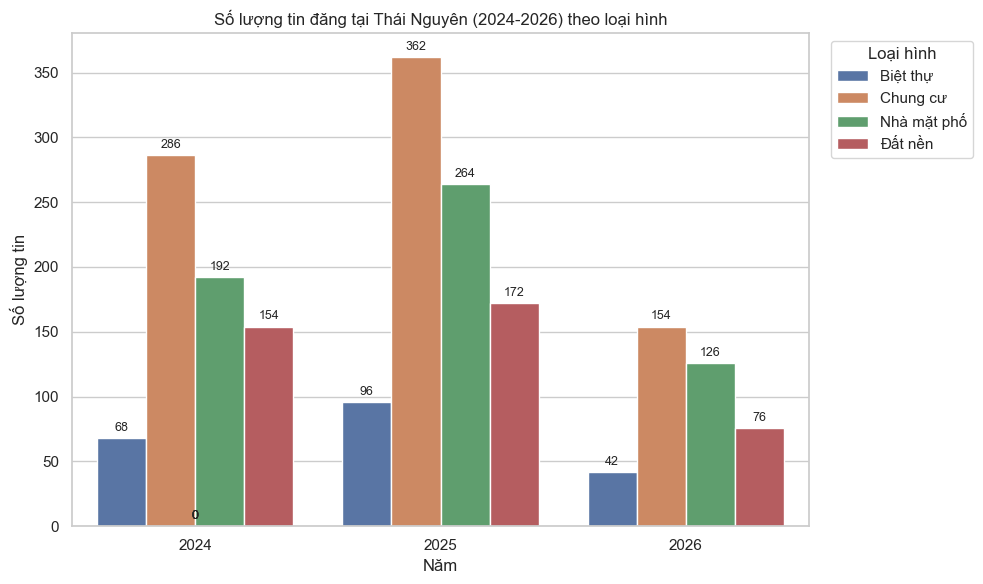

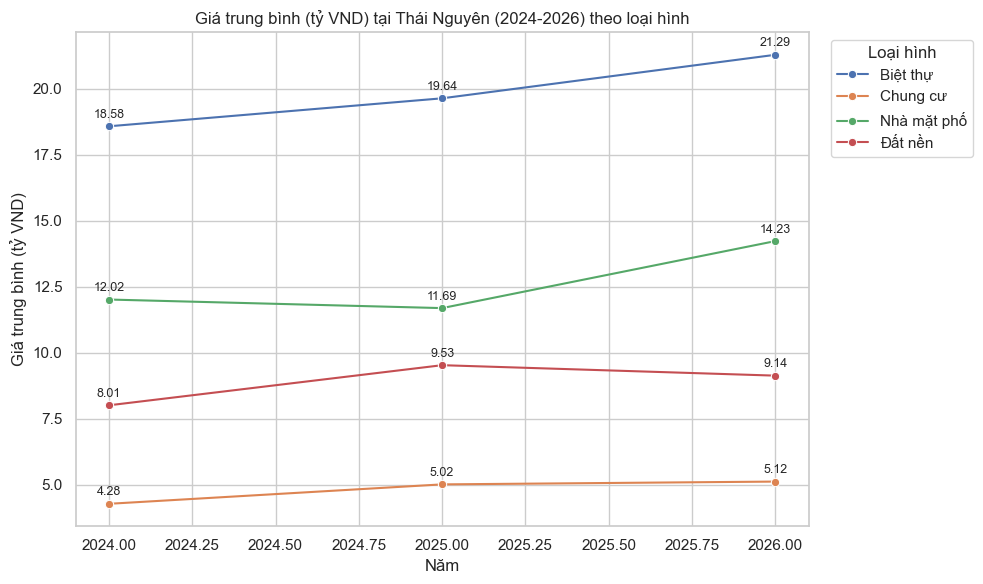

Số lượng theo năm và loại hình:
 nam_dang_tin loai_bat_dong_san  count
         2024          Biệt thự     68
         2024          Chung cư    286
         2024       Nhà mặt phố    192
         2024           Đất nền    154
         2025          Biệt thự     96
         2025          Chung cư    362
         2025       Nhà mặt phố    264
         2025           Đất nền    172
         2026          Biệt thự     42
         2026          Chung cư    154
         2026       Nhà mặt phố    126
         2026           Đất nền     76

Giá trung bình theo năm và loại hình:
 nam_dang_tin loai_bat_dong_san  avg_price
         2024          Biệt thự  18.583382
         2024          Chung cư   4.279825
         2024       Nhà mặt phố  12.019219
         2024           Đất nền   8.012078
         2025          Biệt thự  19.643333
         2025          Chung cư   5.015525
         2025       Nhà mặt phố  11.694394
         2025           Đất nền   9.531686
         2026          Biệt thự  21

In [6]:
th_2024_2026 = th[th['nam_dang_tin'].between(2024, 2026)]
trend_count = th_2024_2026.groupby(['nam_dang_tin','loai_bat_dong_san'])['ma_tin'].count().reset_index(name='count')
trend_avg = th_2024_2026.groupby(['nam_dang_tin','loai_bat_dong_san'])['gia_ban_ty_vnd'].mean().reset_index(name='avg_price')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# Biểu đồ: số lượng tin đăng theo năm và loại hình
plt.figure(figsize=(10,6))
ax = sns.barplot(data=trend_count, x='nam_dang_tin', y='count', hue='loai_bat_dong_san')
plt.title('Số lượng tin đăng tại Thái Nguyên (2024-2026) theo loại hình')
plt.xlabel('Năm')
plt.ylabel('Số lượng tin')
ax.legend(title='Loại hình', bbox_to_anchor=(1.02, 1), loc='upper left')
# Annotate bar values
for p in ax.patches:
    height = p.get_height()
    if height is None:
        continue
    ax.annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=9, xytext=(0,3), textcoords='offset points')
plt.tight_layout()
plt.show()

# Biểu đồ: giá trung bình theo năm và loại hình
plt.figure(figsize=(10,6))
ax = sns.lineplot(data=trend_avg, x='nam_dang_tin', y='avg_price', hue='loai_bat_dong_san', marker='o')
plt.title('Giá trung bình (tỷ VND) tại Thái Nguyên (2024-2026) theo loại hình')
plt.xlabel('Năm')
plt.ylabel('Giá trung bình (tỷ VND)')
ax.legend(title='Loại hình', bbox_to_anchor=(1.02, 1), loc='upper left')
# Annotate line points
for line in ax.get_lines():
    xdata = line.get_xdata()
    ydata = line.get_ydata()
    for x, y in zip(xdata, ydata):
        ax.annotate(f"{y:.2f}", xy=(x, y), xytext=(0,6), textcoords='offset points', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Số lượng theo năm và loại hình:')
print(trend_count.to_string(index=False))
print('\nGiá trung bình theo năm và loại hình:')
print(trend_avg.to_string(index=False))


## Câu 5: Lựa chọn phù hợp tại Thái Nguyên với các ngân sách 1 tỷ, 5 tỷ, 20 tỷ

In [7]:
try:
    budget = float(input('Nhập ngân sách (tỷ VND): '))
except Exception:
    budget = 3.0
    print('Không thể nhập tương tác trong môi trường này. Dùng ngân sách mặc định =', budget, 'tỷ VND')

sort_options = {
    'giá/m2': 'gia_m2',
    'diện tích': 'dien_tich_m2',
    'giá bán': 'gia_ban_ty_vnd',
    'số phòng ngủ': 'so_phong_ngu'
}

try:
    sort_choice = input('Chọn tiêu chí sắp xếp (giá/m2, diện tích, giá bán, số phòng ngủ): ').strip().lower()
except Exception:
    sort_choice = 'giá/m2'
    print('Không thể nhập tương tác trong môi trường này. Dùng tiêu chí mặc định =', sort_choice)

sort_key = sort_options.get(sort_choice, 'gia_m2')
if sort_choice not in sort_options:
    print(f'Tiêu chí không hợp lệ, dùng mặc định: giá/m2')

try:
    df
except NameError:
    import pandas as pd
    path = 'batdongsan_vietnam1.csv'
    df = pd.read_csv(path)
    df['gia_m2'] = (df['gia_ban_ty_vnd'] * 1000 / df['dien_tich_m2']).round(2)
    df['tinh_thanh'] = df['tinh_thanh'].str.strip()
    print('Tải lại dữ liệu từ', path)

try:
    th
except NameError:
    th = df[df['tinh_thanh'] == 'Thái Nguyên'].copy()
    print('Thiết lập lại bộ dữ liệu Thái Nguyên từ df.')

def get_options_for_budget(budget, sort_key='gia_m2', top_n=20):
    """Hiển thị các lựa chọn phù hợp với ngân sách (tỷ VND)."""
    matches = th[th['gia_ban_ty_vnd'] <= budget].copy()
    total = len(matches)
    matches = matches.sort_values(sort_key, ascending=False).head(top_n)
    matches['gia_m2'] = matches['gia_m2'].round(2)
    print(f'Budget <= {budget} tỷ: {total} listings, sắp xếp theo {sort_key} (giảm dần)')
    if total > 0:
        print(matches[['loai_bat_dong_san','dien_tich_m2','so_phong_ngu','gia_ban_ty_vnd','gia_m2']].to_string(index=False))
    else:
        print('No listings available')

get_options_for_budget(budget, sort_key=sort_key)

Budget <= 6.0 tỷ: 868 listings, sắp xếp theo gia_m2 (giảm dần)
loai_bat_dong_san  dien_tich_m2  so_phong_ngu  gia_ban_ty_vnd  gia_m2
         Biệt thự            37             2            4.40  118.92
         Biệt thự            48             2            5.15  107.29
         Biệt thự            37             2            3.79  102.43
         Biệt thự            31             4            3.16  101.94
         Biệt thự            59             4            5.94  100.68
         Biệt thự            38             4            3.71   97.63
      Nhà mặt phố            58             4            5.65   97.41
      Nhà mặt phố            36             1            3.44   95.56
      Nhà mặt phố            45             2            4.25   94.44
      Nhà mặt phố            50             5            4.45   89.00
      Nhà mặt phố            61             2            5.39   88.36
         Biệt thự            64             3            5.53   86.41
      Nhà mặt phố          

### Gợi ý lựa chọn
- 1 tỷ: ưu tiên căn chung cư nhỏ hoặc đất nền nhỏ, phù hợp 1-2 người hoặc gia đình nhỏ.
- 5 tỷ: có thể chọn chung cư rộng hơn, nhà phố nhỏ hoặc đất nền giá tốt, phù hợp gia đình 4-5 người.
- 20 tỷ: ưu tiên nhà phố và biệt thự có diện tích lớn, phù hợp gia đình 4-5 người hoặc đầu tư.
